In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import numpy as np
from filterpy.kalman import KalmanFilter as KF
from scipy import linalg
from matplotlib import pyplot as plt

import utils_data

In [3]:
dt    = 0.01
omega = 2 * np.pi * 1  # frequency = 1 Hz
q     = 20 # quality
a     = np.array([[0, 1], [-omega**2, -omega/q]])

kf   = KF(dim_x=2, dim_z=1)
kf.F = linalg.expm(a * dt)
kf.H = np.array([[1, 0]])

# initial state and covariances
kf.x = np.array([0., 0.])
kf.P *= np.eye(2)   # uncertainty about the initial condition

# --! here is the point: we assume the measurement is noisy, which it is, but we overestimate our model knowledge 
kf.R *= 0.1  # measurement noise
kf.Q *= 0.01  # process uncertainty

In [4]:
class detuning:
    def __init__(self, pos, vel, dt):
        self.pos_sta = pos
        self.vel_sta = vel
        self.pos_tra = pos
        self.vel_tra = vel
        self.dt  = dt

        self.omega_sta = 2 * np.pi * 1
        self.omega_tra = 2 * np.pi * 1
        self.q_sta     = 20.
        self.mu_tra    = 1

        self.a_sta = np.array([[0, 1], [-self.omega_sta**2, -self.omega_sta/self.q_sta]])

        self.count = 0

    def __call__(self):

        a_new = linalg.expm(self.a_sta * self.dt)
        x_old = np.array([[self.pos_sta], [self.vel_sta]])
        x_new = np.dot(a_new, x_old)
        #new_pos_sta = self.pos_sta + self.vel_sta * self.dt
        #new_vel_sta = self.vel_sta - self.omega_sta**2 * self.pos_sta * self.dt - self.mu_sta * self.vel_sta * self.dt

        self.pos_sta = x_new[0, 0]
        self.vel_sta = x_new[1, 0]

        new_pos_sta = x_new[0]
        new_vel_sta = x_new[1]

        new_pos = new_pos_sta
        new_vel = new_vel_sta

        if self.count * self.dt > 14:
            new_pos_tra = self.pos_tra + self.vel_tra * self.dt
            new_vel_tra = self.vel_tra - self.mu_tra * self.vel_tra * self.dt - self.omega_tra**2 * self.pos_tra * self.dt

            self.pos_tra = new_pos_tra
            self.vel_tra = new_vel_tra

            new_pos += new_pos_tra
            new_vel += new_vel_tra
    
        self.count += 1
        return np.array([new_pos, new_vel])


In [5]:
timeseries_nsample = 200
testdata = utils_data.read_datafile('../../data/kalman/test_sim/eval', timeseries_nsample)

# --! test data is a batch/array with timeseries, so split it along the batch dimension
timeseries = torch.split(testdata, 1, dim=0)

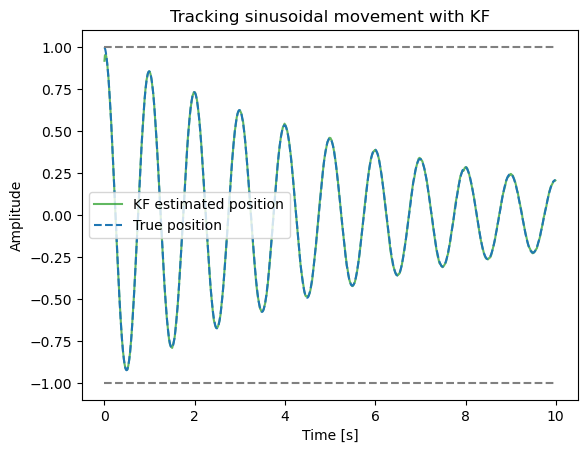

In [6]:
true_pos = []
kf_pos = []

det = detuning(1., 0., dt)

for t in np.arange(0, 10, dt):
    # Simulate true dynamics
    x_true = det()
    z = x_true[0] + np.random.normal(0, 0.01)  # noisy position

    # UKF step
    kf.predict()
    kf.update(np.array([z]))

    # Store
    true_pos.append(x_true[0])
    kf_pos.append(kf.x[0])

t = np.arange(0, 10, dt)
a_up   = np.ones_like(t)
a_down = a_up * -1.

plt.plot(t, kf_pos, label='KF estimated position', color='tab:green', alpha=0.75)
plt.plot(t, true_pos, label='True position', color='tab:blue', alpha=1., linestyle='dashed')
plt.plot(t, a_up, color='gray', linestyle='dashed')
plt.plot(t, a_down, color='gray', linestyle='dashed')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Tracking sinusoidal movement with KF')
plt.show()